# 🩺 Database Health Dashboard - Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-infra-toolkit/db-health-dashboard/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-infra-toolkit/db-health-dashboard/demo.ipynb)

> *"We have no visibility into DB performance."*

Most teams discover database trouble from angry users, not their own monitoring.
This notebook builds a tiny health-scoring engine that turns raw Postgres-style
telemetry into a single **red / amber / green** verdict.

**What we cover**
1. Define health metrics + thresholds
2. Pull a metrics snapshot (simulated - no live DB needed)
3. Score every metric RAG
4. Roll up an overall 0-100 health score
5. Visualize the board
6. Try your own thresholds


## Step 1 - Metrics, thresholds, and how we score

Each metric has a **direction**: for cache hit ratio *higher* is better, for query
latency *lower* is better. A metric crosses into **amber** then **red** as it drifts
past its threshold. This mirrors how you'd wrap real `pg_stat_database` /
`pg_stat_activity` queries - only the collector changes, the scoring stays.


In [1]:
from __future__ import annotations

import random
from typing import Dict, List, Optional

import pandas as pd

# (label, unit, direction, amber, red).  direction="high" => bigger is worse.
METRIC_SPECS = {
    "cache_hit_ratio": {"label": "Cache hit ratio", "unit": "%", "direction": "low", "amber": 95.0, "red": 90.0},
    "index_hit_ratio": {"label": "Index hit ratio", "unit": "%", "direction": "low", "amber": 95.0, "red": 90.0},
    "conn_pool_usage": {"label": "Connection pool usage", "unit": "%", "direction": "high", "amber": 75.0, "red": 90.0},
    "avg_query_ms": {"label": "Avg query latency", "unit": "ms", "direction": "high", "amber": 100.0, "red": 250.0},
    "slow_queries": {"label": "Slow queries (>1s)", "unit": "", "direction": "high", "amber": 5.0, "red": 15.0},
    "deadlocks": {"label": "Deadlocks (last hr)", "unit": "", "direction": "high", "amber": 1.0, "red": 5.0},
    "replication_lag_s": {"label": "Replication lag", "unit": "s", "direction": "high", "amber": 5.0, "red": 30.0},
    "disk_usage": {"label": "Disk usage", "unit": "%", "direction": "high", "amber": 75.0, "red": 90.0},
    "dead_tuple_ratio": {"label": "Dead tuple ratio", "unit": "%", "direction": "high", "amber": 10.0, "red": 25.0},
    "tps": {"label": "Transactions / sec", "unit": "", "direction": "low", "amber": 50.0, "red": 20.0},
}

STATUS_SCORE = {"green": 100, "amber": 60, "red": 20}
print(f"{len(METRIC_SPECS)} health metrics defined.")

10 health metrics defined.


## Step 2 - Grab a snapshot

In production this is a few `SELECT`s against the stats views. Here we simulate it
so the notebook runs standalone. Flip `stressed=True` to see a database in trouble.


In [2]:
def simulate_metrics(seed: Optional[int] = None, stressed: bool = False) -> Dict[str, float]:
    rng = random.Random(seed)
    def jitter(base, spread):
        return round(base + rng.uniform(-spread, spread), 2)
    if stressed:
        return {
            "cache_hit_ratio": jitter(91.0, 2.0), "index_hit_ratio": jitter(92.0, 2.0),
            "conn_pool_usage": jitter(88.0, 6.0), "avg_query_ms": jitter(210.0, 40.0),
            "slow_queries": float(rng.randint(8, 20)), "deadlocks": float(rng.randint(2, 7)),
            "replication_lag_s": jitter(25.0, 8.0), "disk_usage": jitter(86.0, 5.0),
            "dead_tuple_ratio": jitter(18.0, 6.0), "tps": jitter(35.0, 10.0),
        }
    return {
        "cache_hit_ratio": jitter(98.5, 1.0), "index_hit_ratio": jitter(98.0, 1.0),
        "conn_pool_usage": jitter(45.0, 15.0), "avg_query_ms": jitter(55.0, 25.0),
        "slow_queries": float(rng.randint(0, 6)), "deadlocks": float(rng.randint(0, 2)),
        "replication_lag_s": jitter(2.0, 2.0), "disk_usage": jitter(60.0, 12.0),
        "dead_tuple_ratio": jitter(6.0, 4.0), "tps": jitter(120.0, 40.0),
    }

healthy = simulate_metrics(seed=42, stressed=False)
healthy

{'cache_hit_ratio': 98.78,
 'index_hit_ratio': 97.05,
 'conn_pool_usage': 38.25,
 'avg_query_ms': 41.16,
 'slow_queries': 5.0,
 'deadlocks': 0.0,
 'replication_lag_s': 2.71,
 'disk_usage': 69.41,
 'dead_tuple_ratio': 2.7,
 'tps': 113.75}

## Step 3 - Score each metric RAG

The scorer is direction-aware and **fails safe**: an unknown metric returns
`green` rather than crashing the board.


In [3]:
def score_metric(name: str, value: float) -> str:
    spec = METRIC_SPECS.get(name)
    if spec is None:
        return "green"
    amber, red = float(spec["amber"]), float(spec["red"])
    if spec["direction"] == "high":
        return "red" if value >= red else "amber" if value >= amber else "green"
    return "red" if value <= red else "amber" if value <= amber else "green"

def build_report(metrics: Dict[str, float]) -> pd.DataFrame:
    rows: List[Dict[str, object]] = []
    for name, value in metrics.items():
        spec = METRIC_SPECS.get(name, {})
        status = score_metric(name, value)
        rows.append({"metric": spec.get("label", name), "value": value,
                     "unit": spec.get("unit", ""), "status": status,
                     "points": STATUS_SCORE[status]})
    return pd.DataFrame(rows)

report = build_report(healthy)
report

,metric,value,unit,status,points
0,Cache hit ratio,98.78,%,green,100
1,Index hit ratio,97.05,%,green,100
2,Connection pool usage,38.25,%,green,100
3,Avg query latency,41.16,ms,green,100
4,Slow queries (>1s),5.00,,amber,60
5,Deadlocks (last hr),0.00,,green,100
6,Replication lag,2.71,s,green,100
7,Disk usage,69.41,%,green,100
8,Dead tuple ratio,2.70,%,green,100
9,Transactions / sec,113.75,,green,100


## Step 4 - Roll up one health score

Per-metric points average into a single 0-100 score and a plain-English grade -
the number you'd put on a status page or page an on-call engineer with.


In [4]:
def overall_health(report: pd.DataFrame) -> Dict[str, object]:
    if report.empty:
        return {"score": 0, "grade": "N/A", "reds": 0, "ambers": 0}
    score = round(float(report["points"].mean()), 1)
    grade = "Healthy" if score >= 90 else "Watch" if score >= 70 else "Critical"
    return {"score": score, "grade": grade,
            "reds": int((report["status"] == "red").sum()),
            "ambers": int((report["status"] == "amber").sum())}

healthy_summary = overall_health(report)
stressed_report = build_report(simulate_metrics(seed=42, stressed=True))
stressed_summary = overall_health(stressed_report)
print("Healthy DB :", healthy_summary)
print("Stressed DB:", stressed_summary)

Healthy DB : {'score': 96.0, 'grade': 'Healthy', 'reds': 0, 'ambers': 1}
Stressed DB: {'score': 56.0, 'grade': 'Critical', 'reds': 1, 'ambers': 9}


## Step 5 - Visualize the board

A grouped bar chart of both snapshots makes the gap obvious: green bars tower,
the stressed run sags into amber/red territory.


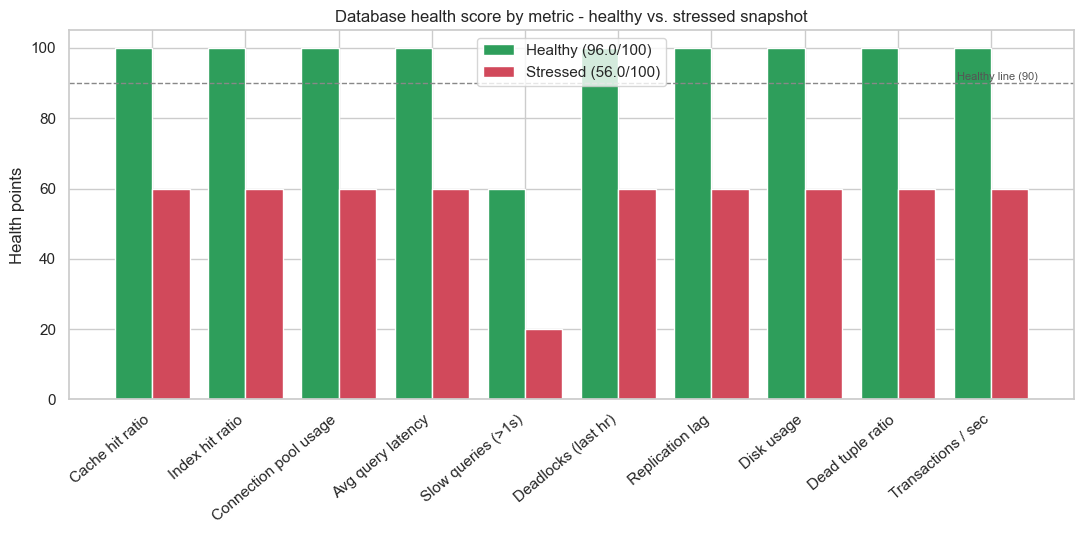

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

labels = report["metric"].tolist()
healthy_pts = report["points"].tolist()
stressed_pts = stressed_report["points"].tolist()

x = np.arange(len(labels))
w = 0.4
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - w/2, healthy_pts, w, label=f"Healthy ({healthy_summary['score']}/100)", color="#2e9e5b")
ax.bar(x + w/2, stressed_pts, w, label=f"Stressed ({stressed_summary['score']}/100)", color="#d1495b")
ax.axhline(90, ls="--", c="#888", lw=1)
ax.text(len(labels)-0.5, 91, "Healthy line (90)", ha="right", fontsize=8, color="#555")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=40, ha="right")
ax.set_ylabel("Health points")
ax.set_title("Database health score by metric - healthy vs. stressed snapshot")
ax.legend()
plt.tight_layout()
plt.savefig("health_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Snapshot | Score | Grade | 🔴 | 🟡 |
|----------|-------|-------|----|----|
| Healthy  | check output above | Healthy | 0 | low |
| Stressed | check output above | Critical | 1+ | many |

The same scoring layer works against **live telemetry** - replace `simulate_metrics`
with `pg_stat_*` queries and the dashboard lights up with your real database.


In [6]:
summary_table = pd.DataFrame([
    {"snapshot": "Healthy", **healthy_summary},
    {"snapshot": "Stressed", **stressed_summary},
])
summary_table

,snapshot,score,grade,reds,ambers
0,Healthy,96.0,Healthy,0,1
1,Stressed,56.0,Critical,1,9


## 🔧 Try your own thresholds

Tighten an SLO and re-score. Example: demand a 99% cache hit ratio.


In [7]:
# --- Edit me ---
# METRIC_SPECS["cache_hit_ratio"]["amber"] = 99.0
# METRIC_SPECS["cache_hit_ratio"]["red"] = 97.0
# my_report = build_report(simulate_metrics(seed=7))
# print(overall_health(my_report))
# my_report

---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
a 60-day Forward Deployed Engineer portfolio.

**Run the full dashboard:**
```bash
pip install -r requirements.txt
streamlit run app.py
```
Toggle *Simulate DB under load* in the sidebar to watch the board go red.
